# scGPT-only single-cell embedding analysis

This notebook runs a **scGPT-only** analysis.

Important framing:

- scGPT is used here as a **pretrained embedding model**.
- We are **not training scGPT**.
- The notebook extracts cell embeddings from a local scGPT checkpoint and stores them in:

```python
adata.obsm["X_scgpt"]
```

Then it builds:

```text
scGPT embedding → neighbor graph → UMAP → Leiden clustering → diagnostics / optional metrics
```

This notebook is intentionally separate from PCA and scVI so each method can be understood independently.


## 1. What this notebook does

The workflow:

```text
load dataset
→ standardize metadata
→ QC and filtering
→ preserve raw counts
→ normalize/log-transform
→ select HVGs
→ verify gene symbols for scGPT
→ load pretrained scGPT checkpoint
→ extract scGPT embeddings
→ build neighbor graph in scGPT space
→ UMAP + Leiden clustering
→ optional biological metrics if labels exist
→ batch diagnostics if batches exist
→ save outputs
```

scGPT is more fragile than PCA/scVI because it requires **gene names that match its vocabulary**.  
If your dataset only contains numeric gene IDs, this notebook will stop with a clear error.


In [1]:
# Core imports
from pathlib import Path
import os
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad

# Optional metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Display settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")

print("scanpy:", sc.__version__)


scanpy: 1.11.5


C:\Users\acer\AppData\Local\Temp\ipykernel_23040\4061888254.py:22: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


## 2. Configuration

Edit this cell first.

### Important paths

`model_dir` must point to your downloaded scGPT checkpoint folder.

A valid folder usually contains files such as:

```text
args.json
best_model.pt
vocab.json
```

For example:

```text
models/scgpt/scGPT_human/
```

### Input modes

This notebook supports:

- `scvi_pbmc_dataset`: loads `scvi.data.pbmc_dataset()`
- `scanpy_pbmc3k`: loads `scanpy.datasets.pbmc3k()`
- `h5ad`: loads your own `.h5ad` file

For serious label-based metrics, use a dataset with independent labels.


In [15]:
# Detect project root.
# If the notebook is inside /notebooks, project root is one level above.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports"

for d in [RAW_DIR, PROCESSED_DIR, RESULTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # Dataset options: "scvi_pbmc_dataset", "scanpy_pbmc3k", "h5ad"
    "input_mode": "scvi_pbmc_dataset",
    "input_h5ad": None,

    "dataset_name": "pbmc_scvi_dataset_scgpt_only",

    # Metadata columns in the raw dataset.
    # If unavailable, set to None.
    "label_key": "labels",
    "batch_key": "batch",

    # scGPT checkpoint path.
    # Change this to the folder containing args.json, best_model.pt, vocab.json.
    "model_dir": str(PROJECT_ROOT / "models" / "scgpt"),

    # Candidate gene-symbol columns. The notebook will choose the one with best vocab match.
    "gene_col_candidates": [
        "gene_symbols",
        "gene_symbol",
        "feature_name",
        "gene_name",
        "symbol",
    ],

    # QC
    "min_genes_per_cell": 200,
    "max_genes_per_cell": None,
    "min_cells_per_gene": 3,
    "max_pct_mt": 20,

    # Normalization / HVG
    "target_sum": 1e4,
    "n_top_hvgs": 2000,
    "hvg_flavor": "seurat",
    "use_batch_key_for_hvg": False,

    # scGPT embedding parameters
    # For CPU debugging, 512 is much faster than the usual 1200.
    # For final analysis, consider 1200 if runtime is acceptable.
    "max_length": 512,
    "batch_size": 32,
    "device": "cpu",
    "use_fast_transformer": False,

    # Graph / clustering
    "n_neighbors": 15,
    "leiden_resolution": 0.5,
    "random_state": 0,

    # Caching
    "use_cache": True,
    "overwrite_cache": False,
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("scGPT model_dir:", CONFIG["model_dir"])


PROJECT_ROOT: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark
RAW_DIR: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw
PROCESSED_DIR: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\processed
scGPT model_dir: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\models\scgpt


## 3. Windows compatibility patch for scGPT

On Windows, scGPT may fail with errors like:

```text
AttributeError: module 'os' has no attribute 'sched_getaffinity'
```

or:

```text
Can't pickle local object 'get_batch_cell_embeddings.<locals>.Dataset'
```

This patch forces scGPT's internal PyTorch DataLoader to use `num_workers=0`.

Run this before calling `scgpt.tasks.embed_data()`.


In [3]:
def patch_windows_scgpt_dataloader():
    """Force scGPT to use num_workers=0 on Windows-like environments."""
    import os

    # scGPT internally uses len(os.sched_getaffinity(0)) to choose DataLoader workers.
    # Returning an empty set forces num_workers=0.
    os.sched_getaffinity = lambda pid: set()

    try:
        import scgpt.tasks.cell_emb as cell_emb
        cell_emb.os.sched_getaffinity = lambda pid: set()
    except Exception as e:
        print("Could not patch scgpt.tasks.cell_emb yet:", repr(e))

    print("sched_getaffinity patched. Worker count will be:", len(os.sched_getaffinity(0)))


patch_windows_scgpt_dataloader()


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scgpt\model\model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scgpt\model\multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sched_getaffinity patched. Worker count will be: 0


## 4. Load dataset

This cell loads the dataset and prints the structure.

For scGPT, gene names matter. Later we will check whether gene symbols match the scGPT vocabulary.


In [4]:
def load_dataset(config):
    mode = config["input_mode"]

    if mode == "scvi_pbmc_dataset":
        import scvi
        adata = scvi.data.pbmc_dataset(remove_extracted_data=False)

    elif mode == "scanpy_pbmc3k":
        adata = sc.datasets.pbmc3k()

    elif mode == "h5ad":
        if config["input_h5ad"] is None:
            raise ValueError("CONFIG['input_h5ad'] must be set when input_mode='h5ad'.")
        adata = sc.read_h5ad(config["input_h5ad"])

    else:
        raise ValueError(f"Unknown input_mode: {mode}")

    adata.var_names_make_unique()
    return adata


adata = load_dataset(CONFIG)

print(adata)
print("\nobs columns:", list(adata.obs.columns))
print("\nvar columns:", list(adata.var.columns))
print("\nfirst var_names:", list(adata.var_names[:10]))


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     File data/gene_info_pbmc.csv already downloaded                                                           
INFO     File data/pbmc_metadata.pickle already downloaded                                                         
INFO     Downloading file at data/pbmc8k\filtered_gene_bc_matrices.tar.gz                                          
Downloading...: 37559it [00:21, 1754.33it/s]                             
INFO     Extracting tar file                                                                                       
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 12269 genes that are detected in less than 1 counts
INFO     Downloading file at data/pbmc4k\filtered_gene_bc_matrices.tar.gz                                          
Downloading...: 100%|██████████| 18424/18424.0 [00:08<00:00, 2076.23it/s]
INFO     Extracting tar file                                                                  

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\merge.py:847: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  concat_indices = concat_indices.str.cat(label_col.map(str), sep=index_unique)
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from floa

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts'
    uns: 'cell_types'
    obsm: 'design', 'raw_qc', 'normalized_qc', 'qc_pc'

obs columns: ['n_counts', 'batch', 'labels', 'str_labels']

var columns: ['gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts']

first var_names: ['ENSG00000188976', 'ENSG00000187608', 'ENSG00000149527', 'ENSG00000157881', 'ENSG00000157873', 'ENSG00000130764', 'ENSG00000198912', 'ENSG00000162408', 'ENSG00000204859', 'ENSG00000162413']


## 5. Standardize metadata

The notebook standardizes metadata into:

```python
adata.obs["cell_type"]
adata.obs["batch"]
```

If labels are missing, biological metrics are skipped.  
If batches are missing, batch diagnostics are skipped.


In [5]:
def standardize_metadata(adata, label_key=None, batch_key=None):
    adata = adata.copy()

    if label_key is not None and label_key in adata.obs.columns:
        adata.obs["cell_type"] = adata.obs[label_key].astype("category")
        print(f"Using label_key='{label_key}' as adata.obs['cell_type']")
    else:
        adata.obs["cell_type"] = "unknown"
        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
        print("No valid label_key found. Biological metrics will be skipped.")

    if batch_key is not None and batch_key in adata.obs.columns:
        adata.obs["batch"] = adata.obs[batch_key].astype("category")
        print(f"Using batch_key='{batch_key}' as adata.obs['batch']")
    else:
        adata.obs["batch"] = "batch_0"
        adata.obs["batch"] = adata.obs["batch"].astype("category")
        print("No valid batch_key found. Batch diagnostics will be skipped.")

    return adata


adata = standardize_metadata(
    adata,
    label_key=CONFIG["label_key"],
    batch_key=CONFIG["batch_key"],
)

print("\nCell-type distribution:")
print(adata.obs["cell_type"].value_counts())

print("\nBatch distribution:")
print(adata.obs["batch"].value_counts())


Using label_key='labels' as adata.obs['cell_type']
Using batch_key='batch' as adata.obs['batch']

Cell-type distribution:
cell_type
2    4996
1    2227
0    1621
3    1448
8     463
7     457
5     351
4     339
6      88
Name: count, dtype: int64

Batch distribution:
batch
0    7982
1    4008
Name: count, dtype: int64


## 6. Preserve gene-symbol candidates

scGPT needs gene names that match its vocabulary.  
This section creates candidate columns and later chooses the best one based on vocabulary overlap.

Do **not** use numeric gene IDs like `0, 1, 2, ...` for scGPT.


In [6]:
def add_gene_symbol_candidates(adata):
    adata = adata.copy()

    # Always preserve var_names as a candidate.
    adata.var["var_names_as_symbols"] = adata.var_names.astype(str)

    # If gene_symbols is missing, create a default from var_names.
    # This may or may not be correct; vocabulary matching later will validate it.
    if "gene_symbols" not in adata.var.columns:
        adata.var["gene_symbols"] = adata.var_names.astype(str)

    print("Available var columns:")
    print(list(adata.var.columns))

    print("\nPreview of candidate gene columns:")
    candidate_cols = ["var_names_as_symbols"] + CONFIG["gene_col_candidates"]
    for col in candidate_cols:
        if col in adata.var.columns:
            print(f"\n{col}:")
            print(adata.var[col].astype(str).head(10).tolist())

    return adata


adata = add_gene_symbol_candidates(adata)


Available var columns:
['gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'var_names_as_symbols']

Preview of candidate gene columns:

var_names_as_symbols:
['ENSG00000188976', 'ENSG00000187608', 'ENSG00000149527', 'ENSG00000157881', 'ENSG00000157873', 'ENSG00000130764', 'ENSG00000198912', 'ENSG00000162408', 'ENSG00000204859', 'ENSG00000162413']

gene_symbols:
['NOC2L', 'ISG15', 'PLCH2', 'PANK4', 'TNFRSF14', 'LRRC47', 'C1orf174', 'NOL9', 'ZBTB48', 'KLHL21']


## 7. Quality control

We compute common QC metrics:

- `total_counts`: total expression per cell
- `n_genes_by_counts`: number of detected genes per cell
- `pct_counts_mt`: percentage of mitochondrial counts

High mitochondrial percentage may indicate damaged cells.


In [7]:
# Mitochondrial genes: human gene symbols often start with 'MT-'.
# If var_names are Ensembl IDs, this may detect zero mitochondrial genes.
# That is acceptable; pct_counts_mt will simply not be informative.
adata.var["mt"] = adata.var_names.astype(str).str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_cols = ["total_counts", "n_genes_by_counts"]
if "pct_counts_mt" in adata.obs.columns:
    qc_cols.append("pct_counts_mt")

adata.obs[qc_cols].describe()


,total_counts,n_genes_by_counts,pct_counts_mt
count,11990.000000,11990.000000,11990.0
mean,1481.968994,457.810425,0.0
std,762.909729,155.410545,0.0
min,382.000000,195.000000,0.0
25%,1034.000000,359.000000,0.0
50%,1290.000000,420.000000,0.0
75%,1645.000000,505.000000,0.0
max,11447.000000,1721.000000,0.0


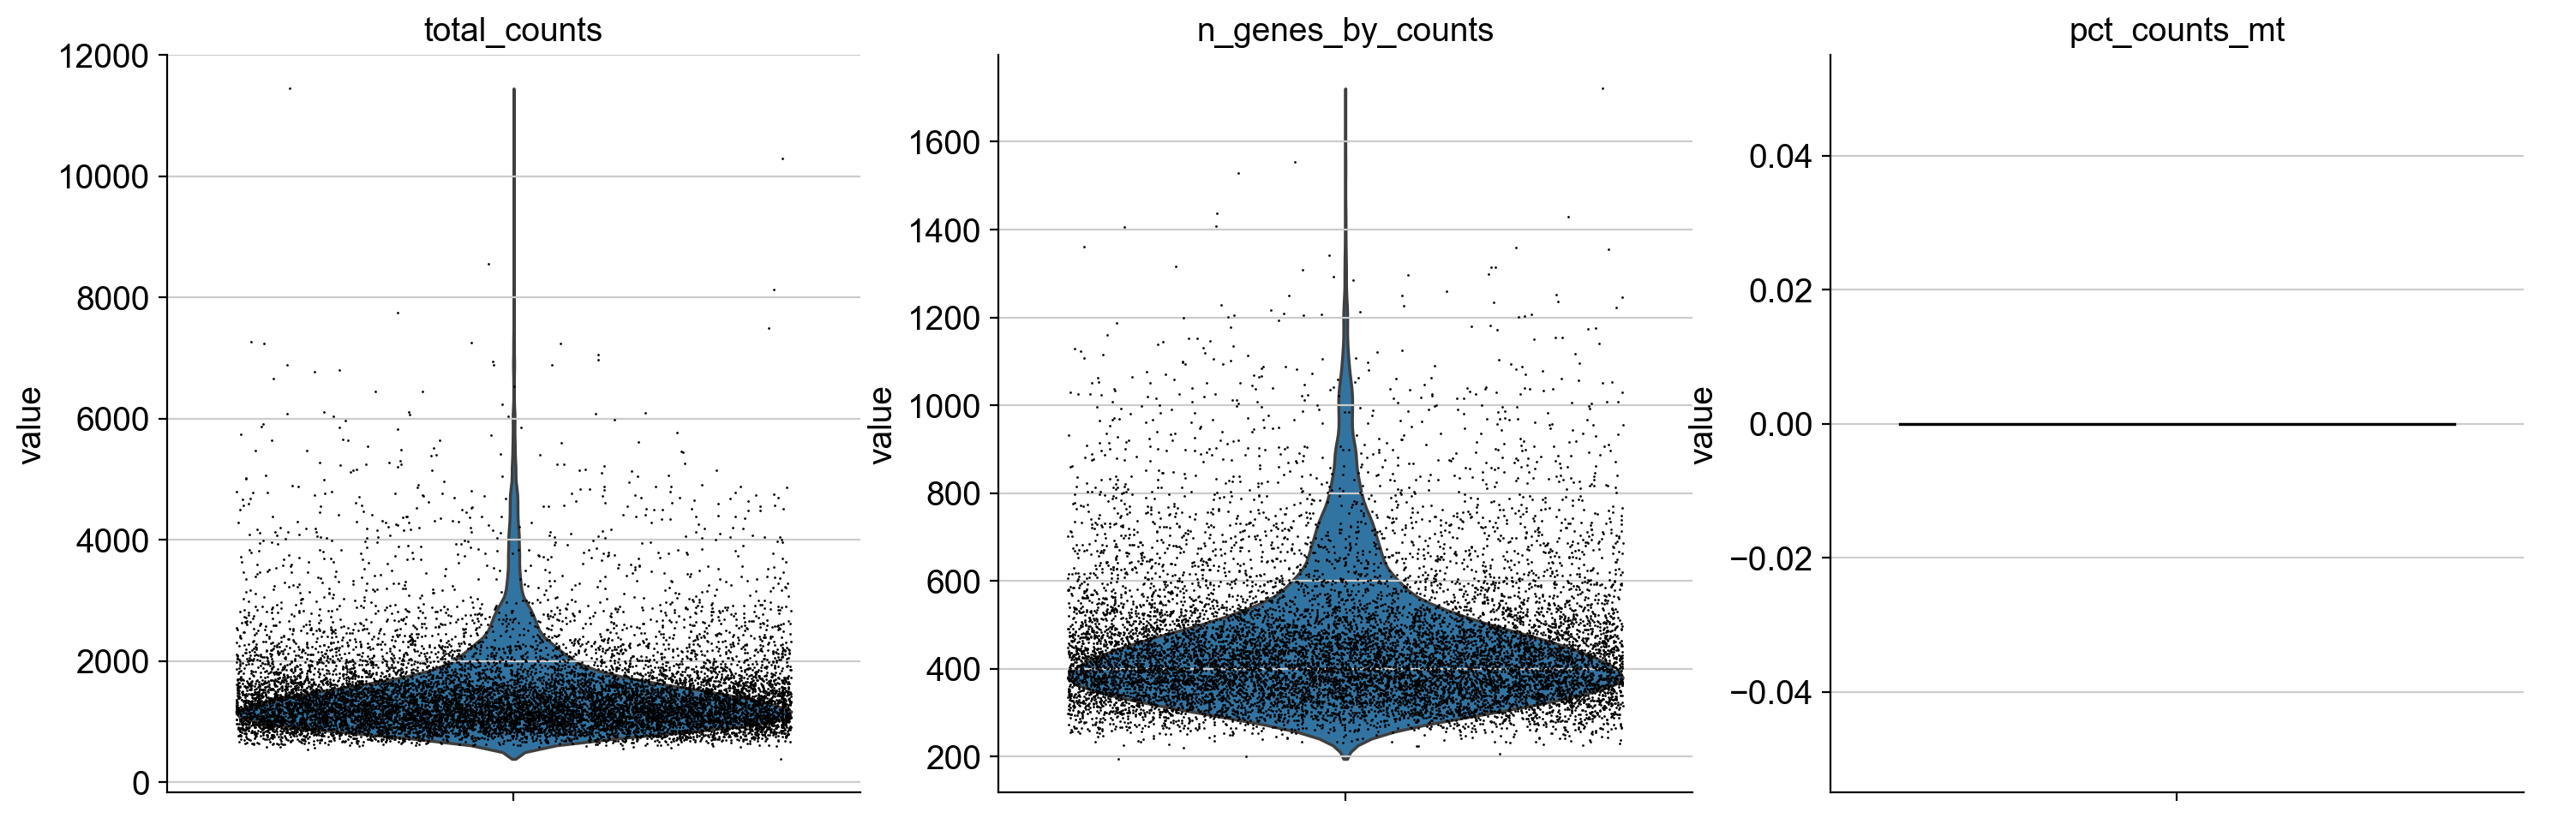

In [8]:
sc.pl.violin(
    adata,
    qc_cols,
    jitter=0.4,
    multi_panel=True,
    show=True,
)


## 8. Filter cells and genes

Filtering removes clear technical outliers and very rare genes.

The defaults are conservative:

- remove cells with fewer than 200 detected genes
- remove genes detected in fewer than 3 cells
- optionally remove cells with high mitochondrial percentage


In [9]:
print("Before filtering:", adata)

sc.pp.filter_cells(adata, min_genes=CONFIG["min_genes_per_cell"])

if CONFIG["max_genes_per_cell"] is not None:
    adata = adata[adata.obs["n_genes_by_counts"] <= CONFIG["max_genes_per_cell"]].copy()

sc.pp.filter_genes(adata, min_cells=CONFIG["min_cells_per_gene"])

if "pct_counts_mt" in adata.obs.columns and CONFIG["max_pct_mt"] is not None:
    # Only apply if mitochondrial percentages were meaningfully computed.
    if np.nanmax(adata.obs["pct_counts_mt"].values) > 0:
        adata = adata[adata.obs["pct_counts_mt"] < CONFIG["max_pct_mt"]].copy()

print("After filtering:", adata)


Before filtering: AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'var_names_as_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_types'
    obsm: 'design', 'raw_qc', 'normalized_qc', 'qc_pc'
filtered out 1 cells that have less than 200 genes expressed
After filtering: AnnData object with n_obs × n_vars = 11989 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'var_names_as_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'cell_types'
    obsm: 'design', 'raw_qc', 'normalized_qc', 'qc_pc'


## 9. Save raw counts, normalize, log-transform

We store the raw count matrix in:

```python
adata.layers["counts"]
```

Then `adata.X` is normalized and log-transformed.

For scGPT embedding extraction, this notebook uses the normalized/log-transformed `adata.X` by default.


In [10]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=CONFIG["target_sum"])
sc.pp.log1p(adata)

# Store a full normalized copy before HVG subsetting.
adata.raw = adata.copy()

print("Stored raw counts in adata.layers['counts']")
print("adata.X now contains normalized/log-transformed expression.")


normalizing counts per cell
    finished (0:00:00)
Stored raw counts in adata.layers['counts']
adata.X now contains normalized/log-transformed expression.


## 10. Highly variable genes

HVG selection keeps the genes that carry the most useful cell-to-cell variation.

For this scGPT-only notebook, we avoid batch-aware HVG selection by default because it can fail on some datasets and complicates the baseline.


HVG kwargs: {'n_top_genes': 2000, 'flavor': 'seurat'}
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
highly_variable
True     2000
False    1346
Name: count, dtype: int64


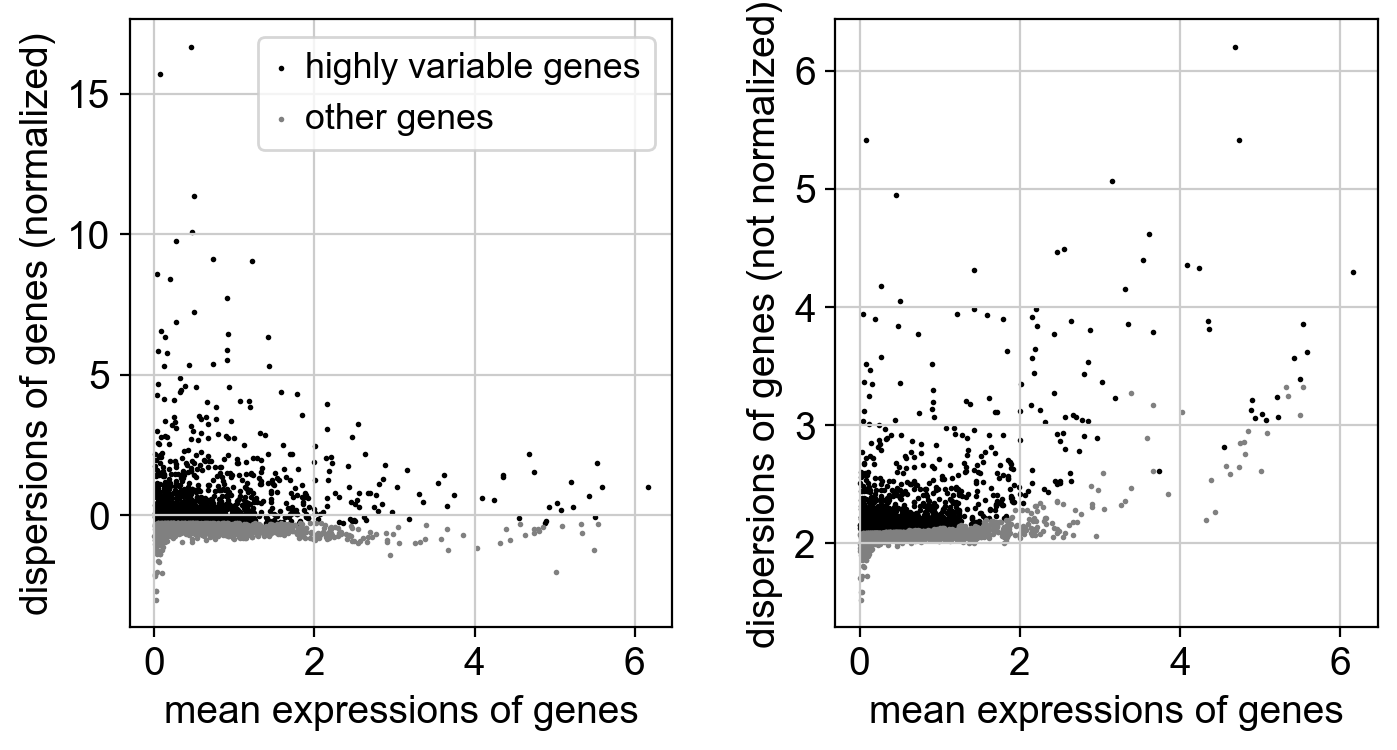

In [11]:
hvg_kwargs = {
    "n_top_genes": CONFIG["n_top_hvgs"],
    "flavor": CONFIG["hvg_flavor"],
}

if CONFIG["use_batch_key_for_hvg"] and adata.obs["batch"].nunique() > 1:
    hvg_kwargs["batch_key"] = "batch"

print("HVG kwargs:", hvg_kwargs)

sc.pp.highly_variable_genes(adata, **hvg_kwargs)

print(adata.var["highly_variable"].value_counts())

sc.pl.highly_variable_genes(adata, show=True)


In [12]:
adata = adata[:, adata.var["highly_variable"]].copy()

# Ensure gene-symbol columns survive HVG subsetting.
print("After HVG subsetting:", adata)
print("var columns:", list(adata.var.columns))


After HVG subsetting: AnnData object with n_obs × n_vars = 11989 × 2000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'var_names_as_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_types', 'log1p', 'hvg'
    obsm: 'design', 'raw_qc', 'normalized_qc', 'qc_pc'
    layers: 'counts'
var columns: ['gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'var_names_as_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']


## 11. Remove cells with zero expression after HVG subsetting

scGPT can crash if a cell has no usable expressed genes after preprocessing.

This check removes cells with zero nonzero values in `adata.X`.


In [13]:
def filter_zero_expression_cells(adata):
    X = adata.X
    if sp.issparse(X):
        n_nonzero = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        n_nonzero = (X > 0).sum(axis=1)

    n_zero = int((n_nonzero == 0).sum())
    print("Cells with zero expressed HVGs:", n_zero)

    if n_zero > 0:
        adata = adata[n_nonzero > 0].copy()
        print("After removing zero-expression cells:", adata)

    return adata


adata = filter_zero_expression_cells(adata)


Cells with zero expressed HVGs: 0


## 12. Verify scGPT checkpoint

The checkpoint folder should contain at least:

```text
vocab.json
args.json
best_model.pt
```

The exact file names may vary slightly, but `vocab.json` is required for vocabulary matching.


In [16]:
model_dir = Path(CONFIG["model_dir"])

print("model_dir:", model_dir)
print("exists:", model_dir.exists())

if not model_dir.exists():
    raise FileNotFoundError(
        f"scGPT model_dir does not exist: {model_dir}\n"
        "Download the scGPT whole-human checkpoint and set CONFIG['model_dir']."
    )

print("Files in model_dir:")
for p in model_dir.iterdir():
    print(" -", p.name)

vocab_path = model_dir / "vocab.json"
if not vocab_path.exists():
    raise FileNotFoundError(f"Missing vocab.json in {model_dir}")

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_json = json.load(f)

vocab_set = set(vocab_json.keys())
print("Vocabulary size:", len(vocab_set))


model_dir: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\models\scgpt
exists: True
Files in model_dir:
 - args.json
 - best_model.pt
 - vocab.json
Vocabulary size: 60697


## 13. Choose the best gene-symbol column

This step checks each candidate gene column against the scGPT vocabulary and chooses the one with the highest match count.

A good match for 2,000 HVGs should usually be in the hundreds or thousands.

If the best match is near zero, this dataset does not contain usable gene symbols for scGPT.


In [17]:
def is_numeric_like(values):
    s = pd.Series(values).astype(str)
    # Fraction of entries that look purely numeric.
    return s.str.fullmatch(r"\d+").fillna(False).mean()


def choose_best_gene_col(adata, vocab_set, candidates):
    # Add var_names candidate.
    all_candidates = ["var_names_as_symbols"] + list(candidates)

    results = []

    for col in all_candidates:
        if col not in adata.var.columns:
            continue

        vals = adata.var[col].astype(str).values
        unique_vals = set(vals)

        match_count = len(unique_vals & vocab_set)
        numeric_fraction = is_numeric_like(vals)

        results.append({
            "column": col,
            "n_unique": len(unique_vals),
            "match_count": match_count,
            "match_fraction_of_genes": match_count / max(1, adata.n_vars),
            "numeric_fraction": numeric_fraction,
        })

    results_df = pd.DataFrame(results).sort_values(
        ["match_count", "match_fraction_of_genes"],
        ascending=False
    )

    if results_df.empty:
        raise ValueError("No candidate gene-symbol columns found in adata.var.")

    best = results_df.iloc[0]

    print("Gene-column vocabulary match summary:")
    display(results_df)

    if best["match_count"] < 100:
        raise ValueError(
            "No usable gene-symbol column found for scGPT. "
            f"Best column was {best['column']} with only {best['match_count']} matches. "
            "You likely need a dataset with gene symbols, not numeric gene IDs."
        )

    if best["numeric_fraction"] > 0.8:
        raise ValueError(
            f"Best gene column {best['column']} appears mostly numeric. "
            "Numeric gene IDs are not usable for scGPT."
        )

    return best["column"], results_df


gene_col, gene_match_table = choose_best_gene_col(
    adata,
    vocab_set=vocab_set,
    candidates=CONFIG["gene_col_candidates"],
)

print("Selected gene_col:", gene_col)


Gene-column vocabulary match summary:


,column,n_unique,match_count,match_fraction_of_genes,numeric_fraction
1,gene_symbols,2000,1950,0.975,0.0
0,var_names_as_symbols,2000,0,0.000,0.0


Selected gene_col: gene_symbols


## 14. Cache utilities

scGPT embeddings are expensive on CPU.  
The pretrained model checkpoint is shared, but embeddings must be cached **per dataset and preprocessing setting**.

Never reuse one dataset's `X_scgpt` for another dataset.


In [18]:
def short_hash(items):
    m = hashlib.md5()
    for x in items:
        m.update(str(x).encode("utf-8"))
        m.update(b"\n")
    return m.hexdigest()[:10]


def make_cache_paths(adata, config, gene_col):
    model_name = Path(config["model_dir"]).name

    obs_hash = short_hash(adata.obs_names.tolist())
    var_hash = short_hash(adata.var[gene_col].astype(str).tolist())

    cache_name = (
        f"{config['dataset_name']}"
        f"__{model_name}"
        f"__hvg{adata.n_vars}"
        f"__maxlen{config['max_length']}"
        f"__obs{obs_hash}"
        f"__var{var_hash}"
    )

    cache_dir = RESULTS_DIR / "embeddings" / config["dataset_name"]
    cache_dir.mkdir(parents=True, exist_ok=True)

    npy_path = cache_dir / f"{cache_name}__X_scgpt.npy"
    meta_path = cache_dir / f"{cache_name}__metadata.json"

    return npy_path, meta_path


def save_embedding_cache(adata, embedding_key, npy_path, meta_path, config, gene_col):
    np.save(npy_path, adata.obsm[embedding_key])

    metadata = {
        "embedding_key": embedding_key,
        "dataset_name": config["dataset_name"],
        "model_dir": config["model_dir"],
        "gene_col": gene_col,
        "max_length": config["max_length"],
        "batch_size": config["batch_size"],
        "n_obs": int(adata.n_obs),
        "n_vars": int(adata.n_vars),
        "obs_names": adata.obs_names.tolist(),
        "gene_values": adata.var[gene_col].astype(str).tolist(),
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)


def load_embedding_cache(adata, embedding_key, npy_path, meta_path, gene_col):
    embedding = np.load(npy_path)

    with open(meta_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    if embedding.shape[0] != adata.n_obs:
        raise ValueError(
            f"Cached embedding has {embedding.shape[0]} cells, "
            f"but current AnnData has {adata.n_obs}."
        )

    if metadata["obs_names"] != adata.obs_names.tolist():
        raise ValueError("Cached embedding cell order does not match current AnnData.")

    if metadata["gene_values"] != adata.var[gene_col].astype(str).tolist():
        raise ValueError("Cached embedding gene order does not match current AnnData.")

    adata.obsm[embedding_key] = embedding
    return adata


cache_npy, cache_meta = make_cache_paths(adata, CONFIG, gene_col)

print("Cache .npy:", cache_npy)
print("Cache metadata:", cache_meta)
print("Cache exists:", cache_npy.exists() and cache_meta.exists())


Cache .npy: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\results\embeddings\pbmc_scvi_dataset_scgpt_only\pbmc_scvi_dataset_scgpt_only__scgpt__hvg2000__maxlen512__obs06c62a8bab__var5d45fcd339__X_scgpt.npy
Cache metadata: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\results\embeddings\pbmc_scvi_dataset_scgpt_only\pbmc_scvi_dataset_scgpt_only__scgpt__hvg2000__maxlen512__obs06c62a8bab__var5d45fcd339__metadata.json
Cache exists: False


## 15. Extract scGPT embeddings

This is the slow step.

It does **not** train scGPT.  
It loads pretrained weights and runs inference over your cells.

If this is slow on CPU, use:

```python
max_length = 256 or 512
batch_size = 16 or 32
```

For final analysis, document the settings you used.


In [19]:
def compute_or_load_scgpt_embeddings(adata, config, model_dir, gene_col, cache_npy, cache_meta):
    embedding_key = "X_scgpt"

    if (
        config["use_cache"]
        and not config["overwrite_cache"]
        and cache_npy.exists()
        and cache_meta.exists()
    ):
        print("Loading cached scGPT embeddings...")
        adata = load_embedding_cache(
            adata,
            embedding_key=embedding_key,
            npy_path=cache_npy,
            meta_path=cache_meta,
            gene_col=gene_col,
        )
        return adata

    print("Computing scGPT embeddings...")
    print("This may be slow on CPU.")

    patch_windows_scgpt_dataloader()

    import scgpt as scg

    # scGPT expects gene_col in adata.var.
    if gene_col not in adata.var.columns:
        raise ValueError(f"gene_col={gene_col} not found in adata.var")

    embedded_adata = scg.tasks.embed_data(
        adata,
        model_dir,
        gene_col=gene_col,
        max_length=config["max_length"],
        batch_size=config["batch_size"],
        device=config["device"],
        use_fast_transformer=config["use_fast_transformer"],
        return_new_adata=True,
    )

    adata.obsm[embedding_key] = np.asarray(embedded_adata.X).copy()

    print("scGPT embedding shape:", adata.obsm[embedding_key].shape)

    if config["use_cache"]:
        save_embedding_cache(
            adata,
            embedding_key=embedding_key,
            npy_path=cache_npy,
            meta_path=cache_meta,
            config=config,
            gene_col=gene_col,
        )
        print("Saved scGPT embedding cache.")

    return adata


adata = compute_or_load_scgpt_embeddings(
    adata,
    config=CONFIG,
    model_dir=model_dir,
    gene_col=gene_col,
    cache_npy=cache_npy,
    cache_meta=cache_meta,
)

print(adata.obsm["X_scgpt"].shape)


Computing scGPT embeddings...
This may be slow on CPU.
sched_getaffinity patched. Worker count will be: 0
scGPT - INFO - match 1950/2000 genes in vocabulary of size 60697.


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\torch\amp\autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Embedding cells:   0%|          | 0/375 [00:00<?, ?it/s]c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\torch\nn\modules\transformer.py:380: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ..\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
Embedding cells: 100%|██████████| 375/375 [42:13<00:00,  6.76s/it]

scGPT embedding shape: (11989, 512)
Saved scGPT embedding cache.
(11989, 512)


## 16. Build neighbor graph, UMAP, and Leiden clustering from scGPT space

The key point:

```python
use_rep="X_scgpt"
```

This tells Scanpy to compute neighbors using the scGPT embedding, not PCA.


In [20]:
sc.pp.neighbors(
    adata,
    n_neighbors=CONFIG["n_neighbors"],
    use_rep="X_scgpt",
    random_state=CONFIG["random_state"],
)

sc.tl.umap(
    adata,
    random_state=CONFIG["random_state"],
)

adata.obsm["X_umap_scgpt"] = adata.obsm["X_umap"].copy()

sc.tl.leiden(
    adata,
    resolution=CONFIG["leiden_resolution"],
    key_added="leiden_scgpt",
    random_state=CONFIG["random_state"],
)

print(adata.obs["leiden_scgpt"].value_counts().sort_index())


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:59)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)
running Leiden clustering


C:\Users\acer\AppData\Local\Temp\ipykernel_23040\3535171449.py:15: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


    finished: found 11 clusters and added
    'leiden_scgpt', the cluster labels (adata.obs, categorical) (0:00:02)
leiden_scgpt
0     2985
1     2268
2     1893
3     1616
4     1588
5      448
6      347
7      320
8      305
9      116
10     103
Name: count, dtype: int64


## 17. UMAP plots

Interpretation:

- Colored by `leiden_scgpt`: computational clusters in scGPT space.
- Colored by `cell_type`: biological labels, if available.
- Colored by `batch`: whether structure is batch-driven.
- Colored by QC metrics: whether structure follows technical variables.


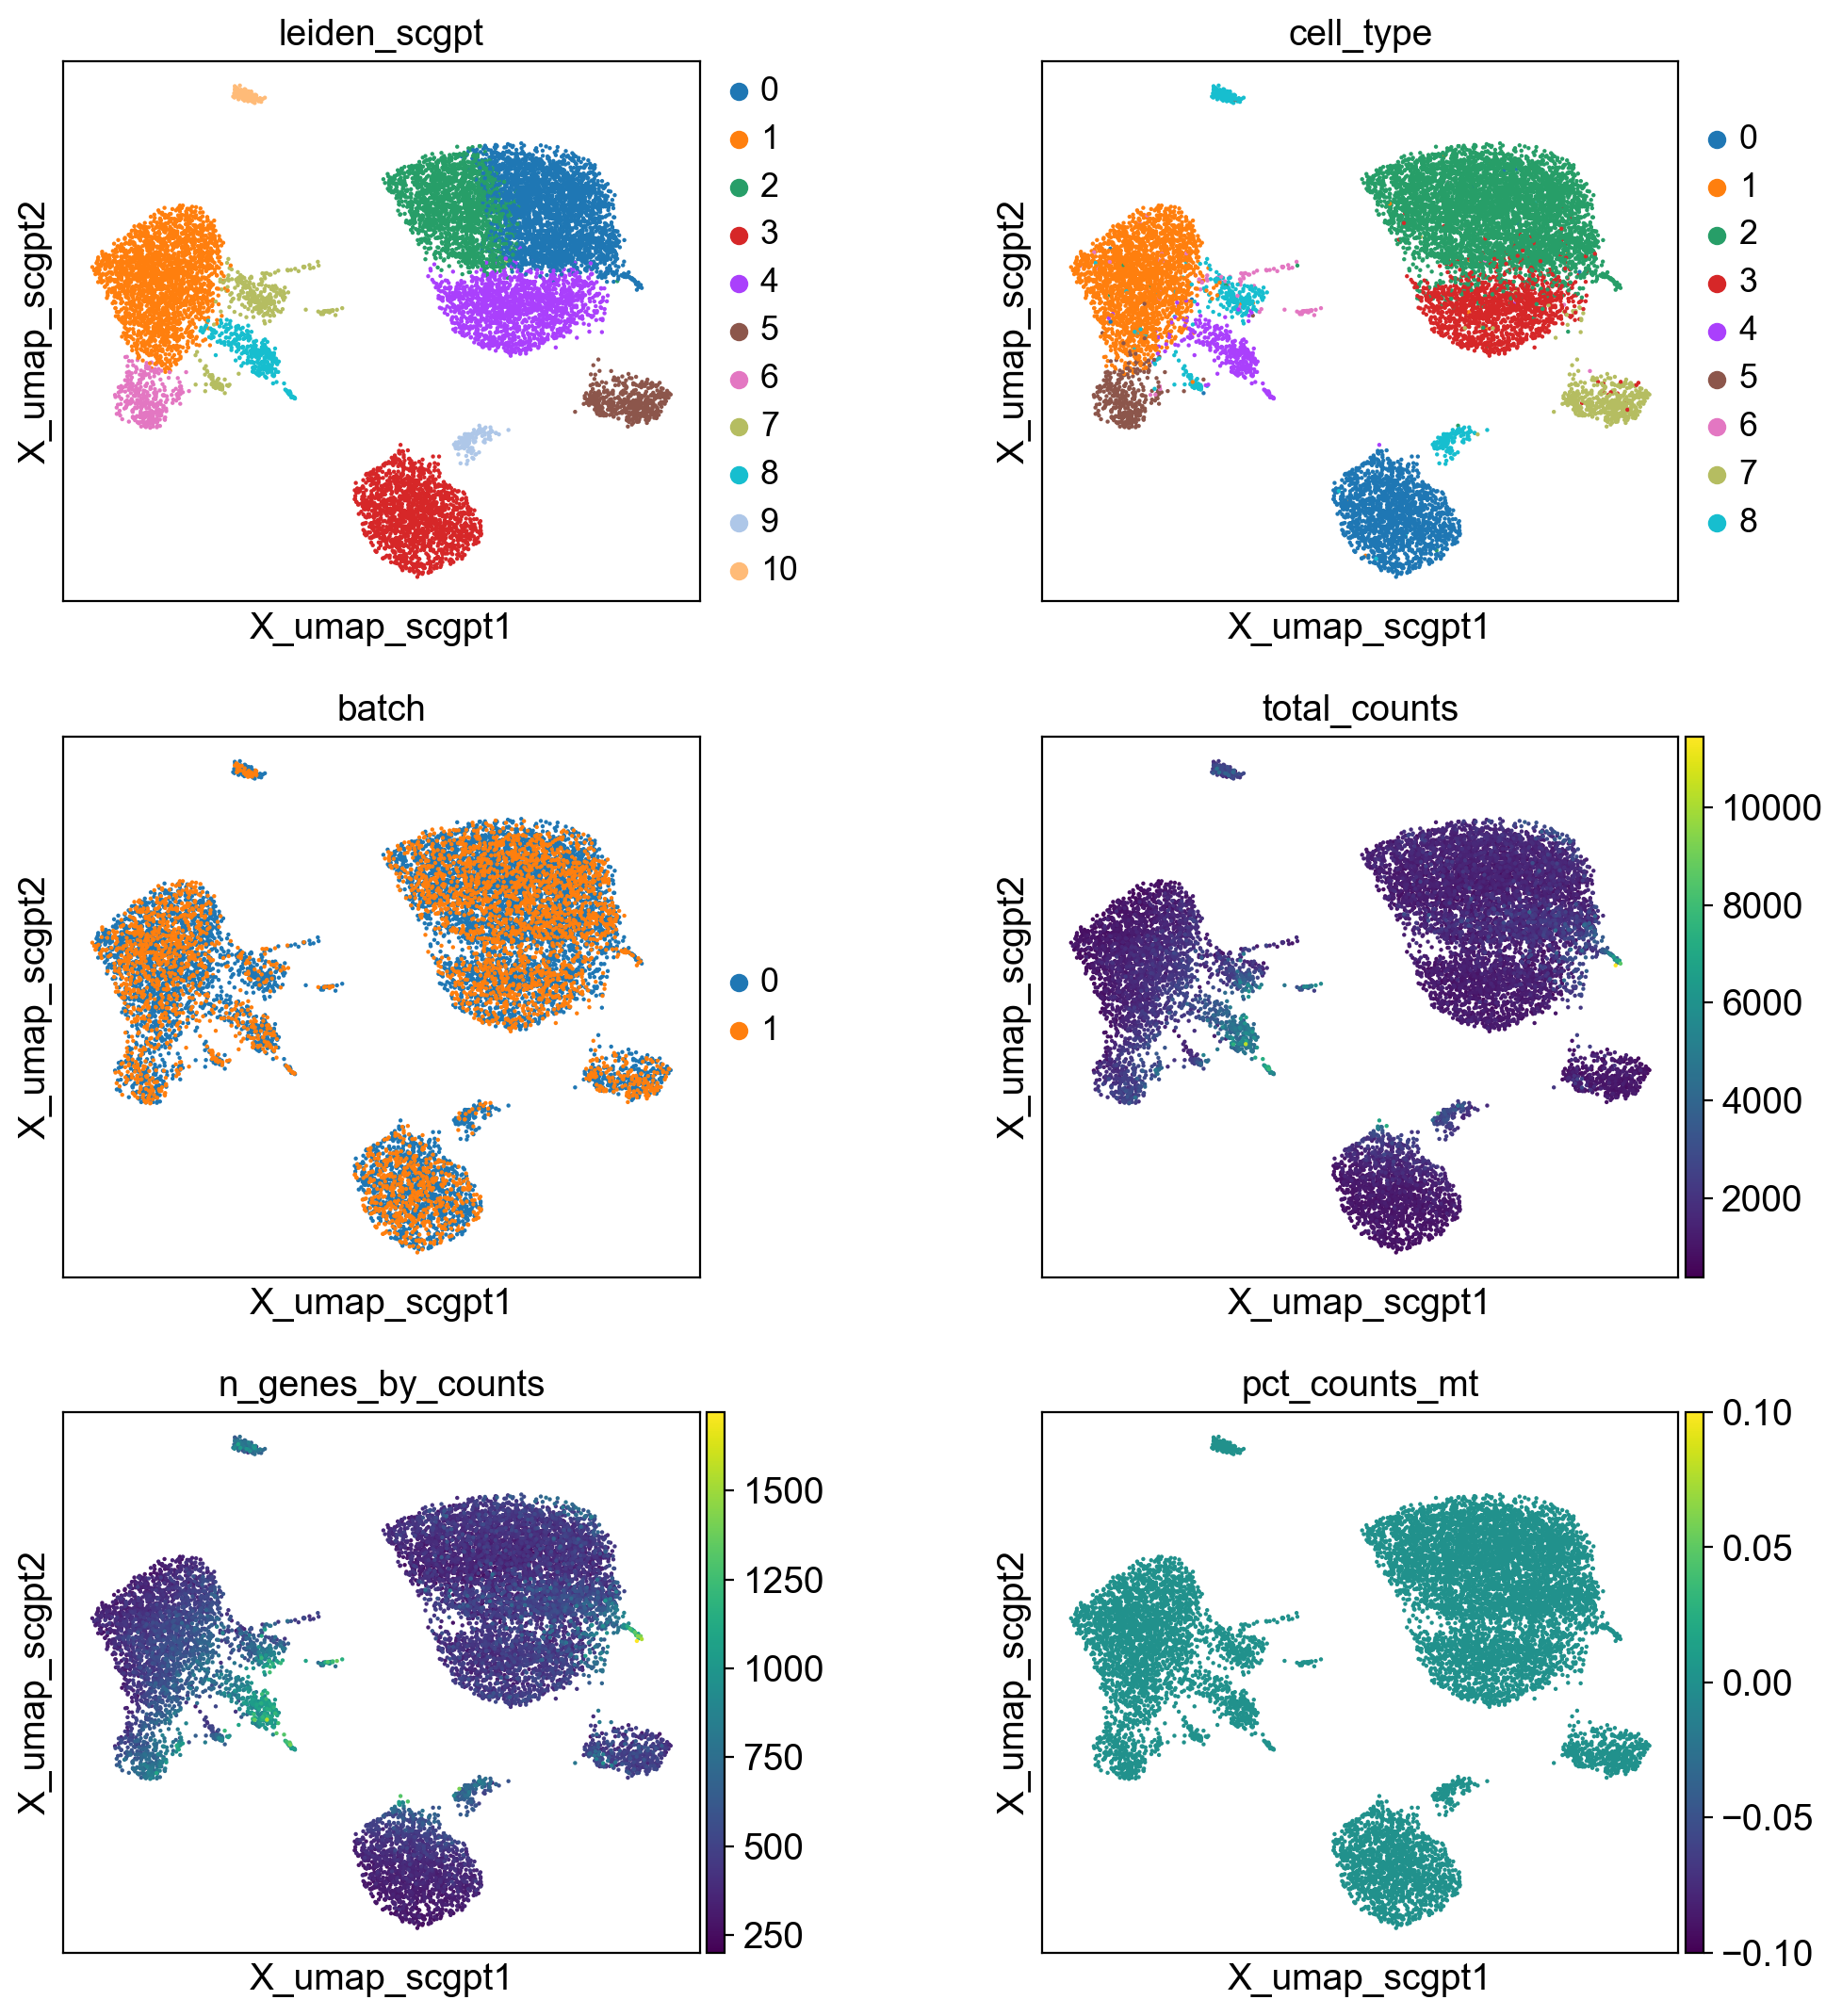

In [21]:
plot_cols = ["leiden_scgpt"]

if adata.obs["cell_type"].nunique() > 1 or list(adata.obs["cell_type"].cat.categories) != ["unknown"]:
    plot_cols.append("cell_type")

if adata.obs["batch"].nunique() > 1:
    plot_cols.append("batch")

for col in ["total_counts", "n_genes_by_counts", "pct_counts_mt"]:
    if col in adata.obs.columns:
        plot_cols.append(col)

sc.pl.embedding(
    adata,
    basis="X_umap_scgpt",
    color=plot_cols,
    wspace=0.4,
    ncols=2,
    show=True,
)


## 18. Cluster composition tables

These tables answer:

1. Are scGPT clusters dominated by one batch?
2. Do scGPT clusters align with independent biological labels?

Rows are Leiden clusters.  
Values are proportions.  
Each row sums to 1.


In [22]:
cluster_key = "leiden_scgpt"

if adata.obs["batch"].nunique() > 1:
    batch_composition = pd.crosstab(
        adata.obs[cluster_key],
        adata.obs["batch"],
        normalize="index",
    )
    print("Batch composition per scGPT cluster:")
    display(batch_composition)
else:
    batch_composition = None
    print("Only one batch detected; skipping batch composition table.")


if adata.obs["cell_type"].nunique() > 1 and "unknown" not in list(adata.obs["cell_type"].cat.categories):
    celltype_composition = pd.crosstab(
        adata.obs[cluster_key],
        adata.obs["cell_type"],
        normalize="index",
    )
    print("Cell-type composition per scGPT cluster:")
    display(celltype_composition)
else:
    celltype_composition = None
    print("No independent cell_type labels; skipping cell-type composition table.")


Batch composition per scGPT cluster:


batch,0,1
leiden_scgpt,,
0,0.671022,0.328978
1,0.662698,0.337302
2,0.674062,0.325938
3,0.656559,0.343441
4,0.651763,0.348237
5,0.631696,0.368304
6,0.636888,0.363112
7,0.743750,0.256250
8,0.645902,0.354098


Cell-type composition per scGPT cluster:


cell_type,0,1,2,3,4,5,6,7,8
leiden_scgpt,,,,,,,,,
0,0.002010,0.001340,0.974539,0.021106,0.000000,0.000335,0.000000,0.000335,0.000335
1,0.001764,0.959436,0.001323,0.000000,0.013668,0.009700,0.005291,0.000000,0.008818
2,0.000528,0.001585,0.988906,0.007924,0.000000,0.000000,0.000528,0.000528,0.000000
3,0.995668,0.001238,0.000619,0.000000,0.000619,0.000000,0.000000,0.000000,0.001856
4,0.000000,0.001259,0.130353,0.855164,0.000630,0.000000,0.000630,0.011965,0.000000
5,0.000000,0.000000,0.000000,0.026786,0.000000,0.000000,0.002232,0.970982,0.000000
6,0.000000,0.051873,0.000000,0.000000,0.000000,0.933718,0.011527,0.000000,0.002882
7,0.003125,0.043750,0.006250,0.000000,0.028125,0.009375,0.215625,0.000000,0.693750
8,0.000000,0.026230,0.000000,0.000000,0.973770,0.000000,0.000000,0.000000,0.000000


## 19. Optional metrics

These are only meaningful if `cell_type` contains independent biological labels.

Metrics:

- **ARI**: agreement between Leiden clusters and labels.
- **NMI**: information overlap between clusters and labels.
- **Silhouette**: separation of labels in scGPT embedding space.

Do not use labels that were created from the same clustering.


In [23]:
metrics = []

has_labels = (
    adata.obs["cell_type"].nunique() > 1
    and "unknown" not in list(adata.obs["cell_type"].cat.categories)
)

if has_labels:
    ari = adjusted_rand_score(
        adata.obs["cell_type"].astype(str),
        adata.obs["leiden_scgpt"].astype(str),
    )

    nmi = normalized_mutual_info_score(
        adata.obs["cell_type"].astype(str),
        adata.obs["leiden_scgpt"].astype(str),
    )

    sil = silhouette_score(
        adata.obsm["X_scgpt"],
        adata.obs["cell_type"].astype(str),
    )

    metrics.append({
        "method": "scGPT",
        "embedding_key": "X_scgpt",
        "cluster_key": "leiden_scgpt",
        "silhouette_bio": sil,
        "ARI_bio": ari,
        "NMI_bio": nmi,
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "max_length": CONFIG["max_length"],
        "batch_size": CONFIG["batch_size"],
        "gene_col": gene_col,
    })

    metrics_df = pd.DataFrame(metrics)
    display(metrics_df)
else:
    metrics_df = pd.DataFrame()
    print("No independent biological labels found. Metrics skipped.")


,method,embedding_key,cluster_key,silhouette_bio,ARI_bio,NMI_bio,n_cells,n_genes,max_length,batch_size,gene_col
0,scGPT,X_scgpt,leiden_scgpt,0.21171,0.674971,0.811515,11989,2000,512,32,gene_symbols


## 20. Save outputs

This saves:

- processed AnnData with `X_scgpt`
- metrics CSV
- gene-match table
- batch/cell-type composition tables if available
- a short Markdown report


In [24]:
dataset_report_dir = REPORTS_DIR / CONFIG["dataset_name"]
dataset_report_dir.mkdir(parents=True, exist_ok=True)

processed_path = PROCESSED_DIR / f"{CONFIG['dataset_name']}_scgpt_only.h5ad"
adata.write(processed_path)

print("Saved AnnData:", processed_path)

# Save metrics
if not metrics_df.empty:
    metrics_path = dataset_report_dir / "scgpt_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print("Saved metrics:", metrics_path)

# Save gene match table
gene_match_path = dataset_report_dir / "scgpt_gene_column_match_table.csv"
gene_match_table.to_csv(gene_match_path, index=False)
print("Saved gene match table:", gene_match_path)

# Save composition tables
if batch_composition is not None:
    batch_path = dataset_report_dir / "scgpt_cluster_batch_composition.csv"
    batch_composition.to_csv(batch_path)
    print("Saved batch composition:", batch_path)

if celltype_composition is not None:
    celltype_path = dataset_report_dir / "scgpt_cluster_celltype_composition.csv"
    celltype_composition.to_csv(celltype_path)
    print("Saved cell-type composition:", celltype_path)


Saved AnnData: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\processed\pbmc_scvi_dataset_scgpt_only_scgpt_only.h5ad
Saved metrics: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scgpt_only\scgpt_metrics.csv
Saved gene match table: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scgpt_only\scgpt_gene_column_match_table.csv
Saved batch composition: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scgpt_only\scgpt_cluster_batch_composition.csv
Saved cell-type composition: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scgpt_only\scgpt_cluster_celltype_composition.csv


In [27]:
report_path = dataset_report_dir / "scgpt_report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"# scGPT-only Report: {CONFIG['dataset_name']}\n\n")
    f.write("## Dataset Summary\n\n")
    f.write(f"- Cells: {adata.n_obs}\n")
    f.write(f"- HVGs used: {adata.n_vars}\n")
    f.write(f"- scGPT embedding dimensions: {adata.obsm['X_scgpt'].shape[1]}\n")
    f.write(f"- Gene column used: `{gene_col}`\n")
    f.write(f"- scGPT model directory: `{CONFIG['model_dir']}`\n")
    f.write(f"- max_length: {CONFIG['max_length']}\n")
    f.write(f"- batch_size: {CONFIG['batch_size']}\n\n")

    f.write("## Metadata\n\n")
    f.write(f"- Cell-type labels available: {has_labels}\n")
    f.write(f"- Number of cell-type categories: {adata.obs['cell_type'].nunique()}\n")
    f.write(f"- Number of batch categories: {adata.obs['batch'].nunique()}\n\n")

    if not metrics_df.empty:
        f.write("## Metrics\n\n")
        f.write(metrics_df.to_markdown(index=False))
        f.write("\n\n")
    else:
        f.write("## Metrics\n\n")
        f.write("Biological metrics were skipped because independent labels were unavailable.\n\n")

    f.write("## Interpretation Notes\n\n")
    f.write(
        "This notebook uses scGPT as a pretrained embedding model. "
        "The model is not fine-tuned or trained on this dataset. "
        "The resulting `X_scgpt` embedding was used to construct a neighbor graph, UMAP, and Leiden clusters. "
        "UMAP plots should be interpreted together with batch and label composition tables.\n"
    )

print("Saved report:", report_path)


Saved report: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scgpt_only\scgpt_report.md


In [26]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


## 21. What to compare later

After you run PCA-only, scVI-only, and scGPT-only notebooks independently, compare them using a separate comparison notebook.

Do not compare methods until each individual notebook runs cleanly.

Final comparison table should include:

```text
method
dataset
silhouette_bio
ARI_bio
NMI_bio
batch diagnostics
runtime
embedding dimensionality
```
